In [18]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from control import TransferFunction, step_response, pzmap, poles, zeros

In [19]:
s = sp.symbols('s')
U, Y = sp.symbols('U Y')

expr = 2*s**2 * Y + s*Y - s*U - U

solution = sp.solve(expr, Y)[0]
G = sp.simplify(solution / U)

print("Transfer Function G(s):", G)

Transfer Function G(s): (s + 1)/(s*(2*s + 1))


In [20]:
num = [float(i) for i in sp.Poly(sp.numer(G), s).all_coeffs()]
den = [float(i) for i in sp.Poly(sp.denom(G), s).all_coeffs()]

sys = TransferFunction(num, den)
print(sys)

<TransferFunction>: sys[6]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


In [21]:
print("Poles:", poles(sys))
print("Zeros:", zeros(sys))

Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


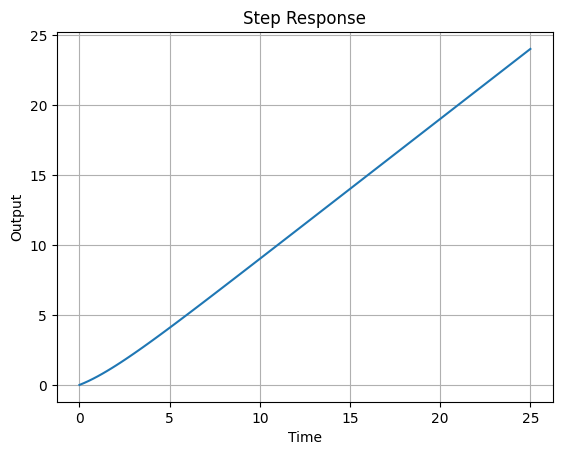

In [22]:
t, y = step_response(sys)

plt.plot(t, y)
plt.title("Step Response")
plt.xlabel("Time")
plt.ylabel("Output")
plt.grid()
plt.show()

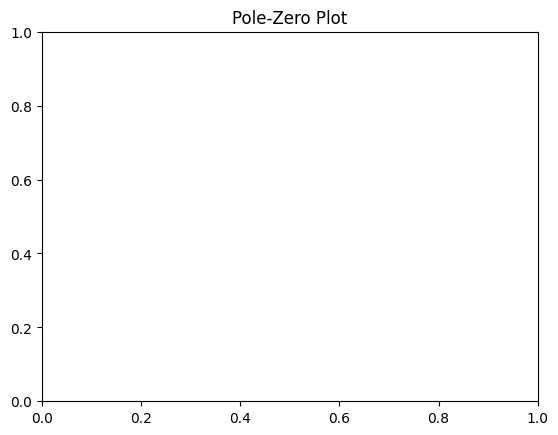

In [23]:
from control import pole_zero_map

pole_zero_map(sys)
plt.title("Pole-Zero Plot")
plt.show()